# Notebook 3 — Le même MLP, en PyTorch

**TP « Du perceptron au MLP » · ~45 min**

Au notebook 2, tu as écrit un réseau de neurones à la main. Ici, on refait **exactement le
même** — même architecture, même compte de paramètres — mais avec PyTorch.

Le but n'est pas d'apprendre une API. C'est de voir que PyTorch ne fait **rien que tu ne
saches déjà faire** : il automatise le backward que tu as écrit, et c'est à peu près tout.

### Ce que tu sauras faire à la fin

1. Traduire ton code NumPy en PyTorch, ligne par ligne.
2. Mener l'**atelier sur le taux d'apprentissage** promis ce matin (slide 7.3).
3. Lire une matrice de confusion et regarder ce que le modèle rate.

In [1]:
import pathlib
import sys

# On retrouve la racine du dépôt, qu'on lance ce notebook depuis notebooks/
# ou depuis notebooks/solutions/.
RACINE = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "mnist.py").exists())
sys.path.insert(0, str(RACINE / "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import mnist
import viz
from couleurs import applique_style

applique_style()
torch.manual_seed(0)
np.random.seed(0)

print("PyTorch", torch.__version__, "— on reste sur CPU, c'est largement suffisant ici.")

PyTorch 2.13.0+cpu — on reste sur CPU, c'est largement suffisant ici.


---
## 1 — La table de traduction

Rien de neuf. Juste une correspondance.

| Ce que tu as écrit au notebook 2 | Ce que PyTorch écrit | Ce que ça change |
|---|---|---|
| `W.append(np.random.randn(...) * ...)` | `nn.Linear(784, 128)` | l'init « He » est faite pour toi |
| `relu(z)` | `nn.ReLU()` | rien |
| `X @ W[0] + b[0]` | `couche(x)` | rien |
| `softmax(...)` + `cross_entropy(...)` | `nn.CrossEntropyLoss()` | **les deux d'un coup**, en plus stable |
| toute la fonction `backward()` | `loss.backward()` | **c'est ça, l'apport de PyTorch** |
| `W[k] = W[k] - eta * dW[k]` | `optimizer.step()` | rien, pour SGD |
| — | `optimizer.zero_grad()` | **nouveau**, et on va voir pourquoi |
| découpage manuel en lots | `DataLoader` | mélange + lots + performance |

La seule vraie nouveauté de la colonne du milieu, c'est `loss.backward()`. Les 20 lignes de
dérivées que tu as écrites hier, PyTorch les reconstruit tout seul en enregistrant les
opérations du forward.

## 2 — Les données

Même chargement qu'au notebook 2 — toujours notre `charge_mnist`, pour que le prétraitement
reste visible. On convertit ensuite en tenseurs.

> **Note.** On n'utilise volontairement pas `torchvision.transforms`. Le fameux
> `Normalize((0.1307,), (0.3081,))` qu'on copie-colle partout n'est rien d'autre que le
> `/255` du notebook 1, suivi d'un centrage. Autant le voir en clair.

In [2]:
from torch.utils.data import TensorDataset, DataLoader

X_train, y_train, X_test, y_test = mnist.charge_mnist(aplati=True, normalise=True)
X_val, y_val = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]


def en_tenseurs(X, y):
    return TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())


train_loader = DataLoader(en_tenseurs(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(en_tenseurs(X_val, y_val), batch_size=512)
test_loader = DataLoader(en_tenseurs(X_test, y_test), batch_size=512)

# Pour les comparaisons de réglages (atelier eta, optimiseurs, taille de couche),
# on utilise un sous-ensemble : on cherche la FORME des courbes, pas le dernier
# dixième de pourcent. Ça rend chaque expérience jouable en séance.
train_rapide = DataLoader(en_tenseurs(X_train[:15000], y_train[:15000]), batch_size=64, shuffle=True)

print(f"{len(train_loader)} lots de 64 par époque ({len(train_rapide)} pour les comparaisons)")

860 lots de 64 par époque (235 pour les comparaisons)


## 3 — Le modèle : 784 → 128 → 64 → 10

Toujours l'architecture de la slide 5.5. `nn.Sequential` empile les couches dans l'ordre —
c'est le forward pass, écrit en déclaratif.

⚠️ **Pas de softmax à la fin.** `nn.CrossEntropyLoss` l'applique lui-même, en interne et de
façon numériquement plus stable. Il attend donc les scores bruts `z` (les *logits*), pas des
probabilités. C'est l'erreur de débutant la plus fréquente en PyTorch : mettre un softmax
avant CrossEntropyLoss, et se retrouver avec un modèle qui apprend mal sans comprendre
pourquoi.

In [3]:
def construit_modele():
    return nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10),      # sortie = z (logits), pas de softmax ici
    )


modele = construit_modele()
n_parametres = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nparamètres : {n_parametres:,}".replace(",", " "))
assert n_parametres == 109_386, "ce doit être le même réseau qu'au notebook 2"
print("→ 109 386, comme au tableau du matin et comme ton code NumPy.")

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

paramètres : 109 386
→ 109 386, comme au tableau du matin et comme ton code NumPy.


## 4 — La boucle d'entraînement

Compare-la à celle du notebook 2. C'est **la même forme** : les 4 boîtes de la slide 6.0,
dans le même ordre.

Deux lignes méritent une explication.

**`optimizer.zero_grad()`** — PyTorch **accumule** les gradients au lieu de les remplacer.
Si tu oublies cette ligne, le gradient du lot 2 s'ajoute à celui du lot 1, puis du lot 3…
et le modèle part en vrille. (Ce comportement n'est pas un caprice : il permet de simuler
de gros lots sur une petite carte graphique. Mais dans 99 % des cas, on veut juste
remettre à zéro.)

**`model.train()` / `model.eval()`** — certaines couches se comportent différemment à
l'entraînement et à l'évaluation (dropout, batch-norm). Notre modèle n'en a pas encore, mais
prends l'habitude : c'est une source de bugs silencieux classique.

In [4]:
def evalue(modele, loader, critere):
    """Renvoie (loss moyenne, accuracy) sans toucher aux gradients."""
    modele.eval()
    perte, justes, total = 0.0, 0, 0
    with torch.no_grad():                      # pas de calcul de gradient : plus rapide
        for x, y in loader:
            z = modele(x)
            perte += critere(z, y).item() * len(y)
            justes += (z.argmax(dim=1) == y).sum().item()
            total += len(y)
    return perte / total, justes / total


def entraine(modele, train_loader, val_loader, eta=0.1, epoques=8, optimiseur="sgd", bavard=True):
    critere = nn.CrossEntropyLoss()
    if optimiseur == "sgd":
        optimizer = torch.optim.SGD(modele.parameters(), lr=eta)
    else:
        optimizer = torch.optim.Adam(modele.parameters(), lr=eta)

    historique = {"train": [], "validation": []}

    for epoque in range(epoques):
        modele.train()
        for x, y in train_loader:
            z = modele(x)                    # 1 · forward
            loss = critere(z, y)             # 2 · loss

            optimizer.zero_grad()
            loss.backward()                  # 3 · backward
            optimizer.step()                 # 4 · update

        loss_train, _ = evalue(modele, train_loader, critere)
        loss_val, acc_val = evalue(modele, val_loader, critere)
        historique["train"].append(loss_train)
        historique["validation"].append(loss_val)
        if bavard:
            print(f"époque {epoque + 1:2d}/{epoques} — loss {loss_train:.4f}"
                  f" — accuracy validation {acc_val:.2%}")

    return historique

In [5]:
modele = construit_modele()
%time historique = entraine(modele, train_loader, val_loader, eta=0.1, epoques=8)

époque  1/8 — loss 0.2661 — accuracy validation 92.64%


époque  2/8 — loss 0.1520 — accuracy validation 95.36%


époque  3/8 — loss 0.1442 — accuracy validation 95.26%


époque  4/8 — loss 0.1525 — accuracy validation 95.08%


époque  5/8 — loss 0.0707 — accuracy validation 97.28%


époque  6/8 — loss 0.0557 — accuracy validation 97.72%


époque  7/8 — loss 0.0506 — accuracy validation 97.84%


époque  8/8 — loss 0.0442 — accuracy validation 97.72%
CPU times: user 1min 3s, sys: 420 ms, total: 1min 4s
Wall time: 33.5 s


accuracy sur le jeu de test : 97.51%


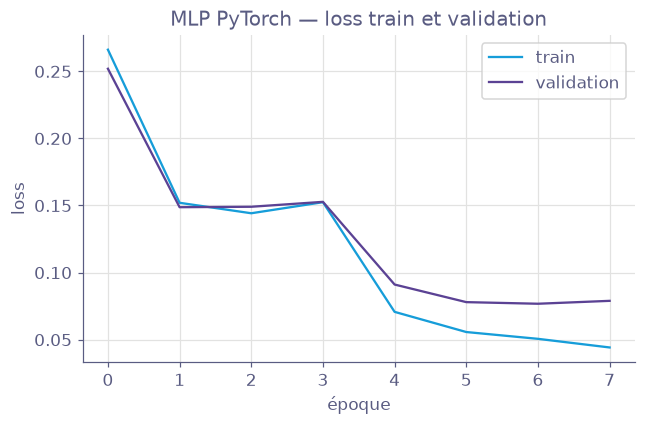

In [6]:
critere = nn.CrossEntropyLoss()
_, accuracy = evalue(modele, test_loader, critere)

print(f"accuracy sur le jeu de test : {accuracy:.2%}")
assert accuracy > 0.97, "on attend plus de 97 %"

viz.plot_courbes(historique, titre="MLP PyTorch — loss train et validation")

### Lire ces deux courbes (slide 6.7)

Trois régimes possibles :

- **Sous-apprentissage** : les deux courbes restent hautes. Le modèle est trop petit, ou pas
  assez entraîné.
- **Bon régime** : les deux descendent ensemble et restent proches. ← *c'est ici qu'on est.*
- **Sur-apprentissage** : la train continue de descendre, la validation **remonte**. Le
  modèle apprend le bruit du jeu d'entraînement par cœur.

C'est précisément pour repérer le troisième cas qu'on garde un jeu de validation.

---
# 5 — L'atelier taux d'apprentissage

**C'est la promesse de la slide 7.3.** Le matin a dit (slide 6.4) : *« trop petit :
convergence lente. Trop grand : on saute par-dessus le minimum. »* C'était un dessin. On va
en faire une mesure.

### Organisation

Chaque binôme prend **un** `eta` de la liste, lance la cellule, et note ce qu'il observe.
On superpose les quatre courbes à la fin.

| `eta` | Prédiction (avant de lancer) | Ce que tu observes |
|---|---|---|
| `1e-5` | ? | |
| `1e-3` | ? | |
| `0.1`  | ? | |
| `10`   | ? | |

**Remplis la colonne « prédiction » avant de lancer.** Se tromper en public sur une
prédiction est la façon la plus efficace d'ancrer une intuition.

In [7]:
resultats = {}

for eta in [1e-5, 1e-3, 0.1, 10.0]:
    torch.manual_seed(0)                       # même point de départ pour tous
    m = construit_modele()
    h = entraine(m, train_rapide, val_loader, eta=eta, epoques=5, bavard=False)
    resultats[f"eta = {eta}"] = h["train"]
    fin = h["train"][-1]
    etat = "diverge" if not np.isfinite(fin) else f"loss finale {fin:.4f}"
    print(f"eta = {eta:<8} → {etat}")

eta = 1e-05    → loss finale 2.3035


eta = 0.001    → loss finale 2.2680


eta = 0.1      → loss finale 0.2173


eta = 10.0     → loss finale 2.5753


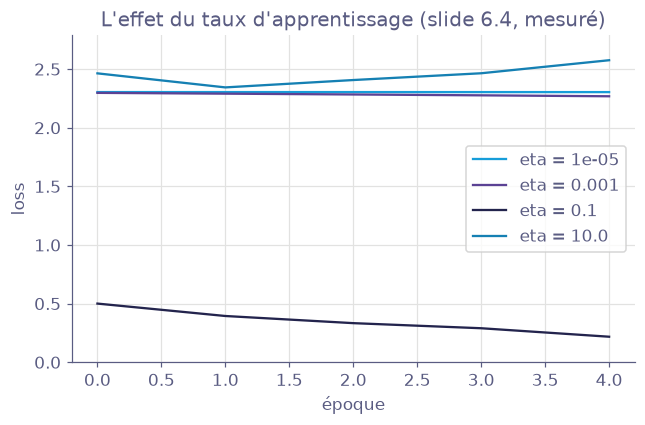

In [8]:
viz.plot_comparaison(resultats, titre="L'effet du taux d'apprentissage (slide 6.4, mesuré)")

### Ce qu'on lit sur ce graphe

Repère d'abord la valeur **2.30**. C'est `log(10)` : la loss d'un modèle qui répond au
hasard entre 10 classes. Toute courbe qui reste à ce niveau **n'a rien appris du tout**.

- **`eta = 1e-5`** — collée à 2.30. Le modèle apprend, mais si lentement qu'il faudrait des
  milliers d'époques pour que ça se voie. *« Trop petit : convergence lente. »*
- **`eta = 1e-3`** — décolle à peine de 2.30 en 5 époques. C'est le même problème, en moins
  extrême : ça finirait par marcher, mais il faudrait être patient.
- **`eta = 0.1`** — la loss chute nettement. C'est notre réglage, et l'écart avec les deux
  précédents est spectaculaire pour un simple changement de nombre.
- **`eta = 10`** — **au-dessus de 2.30**, c'est-à-dire *pire que le hasard*. Chaque pas est
  si grand qu'il envoie les poids plus loin du minimum qu'ils n'en étaient. Avec un `eta`
  encore plus grand, on obtient carrément des `nan`. *« On saute par-dessus le minimum. »*

Note l'asymétrie, elle est utile en pratique : un `eta` **trop petit** te fait juste perdre
du temps, un `eta` **trop grand** t'empêche d'arriver — quel que soit le temps que tu y
passes.

Le `eta` optimal n'est pas une constante universelle : il dépend de l'architecture, de la
normalisation des données et de l'optimiseur. **C'est pour cette raison qu'on le cherche
empiriquement**, en traçant exactement ce graphe.

## 5 bis — Et l'optimiseur ? (slide 6.6)

Le matin a présenté SGD, Momentum et Adam en disant qu'Adam est « le choix par défaut ».
Vérifions ce que ça vaut : même modèle, même `eta = 0.01`, on change juste l'optimiseur.

SGD   → loss finale 1.3507


ADAM  → loss finale 0.1079


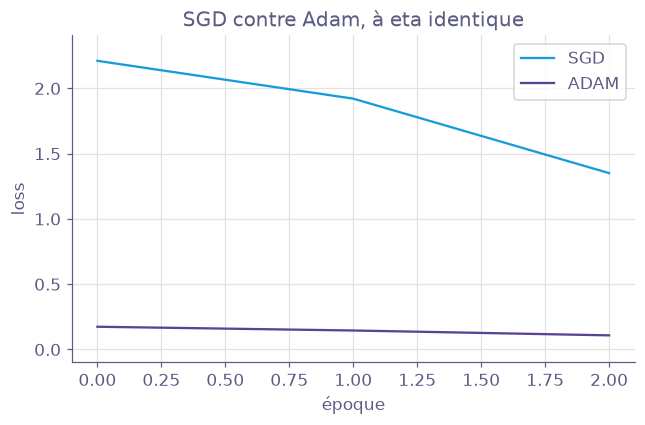

In [9]:
resultats_opt = {}
for nom in ["sgd", "adam"]:
    torch.manual_seed(0)
    m = construit_modele()
    h = entraine(m, train_rapide, val_loader, eta=0.01, epoques=3, optimiseur=nom, bavard=False)
    resultats_opt[nom.upper()] = h["train"]
    print(f"{nom.upper():5} → loss finale {h['train'][-1]:.4f}")

viz.plot_comparaison(resultats_opt, titre="SGD contre Adam, à eta identique")

Avec `eta = 0.01`, SGD traîne — c'est un pas trop petit pour lui. Adam, à `eta` **rigoureusement
identique**, descend environ dix fois plus bas, parce qu'il **adapte un pas différent pour
chaque paramètre** au lieu d'appliquer le même `eta` partout.

C'est pour ça qu'Adam est le choix par défaut : il est nettement moins sensible au réglage
de `eta`. Ce qui ne veut pas dire qu'il faut arrêter de réfléchir — juste qu'on a droit à
plus d'erreur.

---
# 6 — Lire les erreurs du modèle

97 %, c'est un chiffre. Il ne dit **pas** *où* le modèle se trompe. Deux outils pour ça.

### L'accuracy ment quand les classes sont déséquilibrées

MNIST est équilibré (≈ 6 000 exemples par chiffre), donc l'accuracy y est honnête. Mais
fabriquons un jeu déséquilibré pour voir le piège — ça prend 5 secondes et ça évite des
mois de confiance mal placée.

In [10]:
# Un jeu de test où 99 % des exemples sont des 1.
masque_1 = y_test == 1
X_desequilibre = np.concatenate([X_test[masque_1], X_test[~masque_1][:60]])
y_desequilibre = np.concatenate([y_test[masque_1], y_test[~masque_1][:60]])

# Un modèle stupide qui répond toujours "1", sans jamais regarder l'image.
accuracy_stupide = (y_desequilibre == 1).mean()
print(f"accuracy du modèle « je réponds toujours 1 » : {accuracy_stupide:.2%}")
print("→ 95 % d'accuracy, et le modèle ne regarde même pas l'image.")

accuracy du modèle « je réponds toujours 1 » : 94.98%
→ 95 % d'accuracy, et le modèle ne regarde même pas l'image.


### La matrice de confusion

Elle montre **quelle** classe est confondue avec **laquelle**. La diagonale, ce sont les
bonnes réponses ; tout ce qui est à côté est une erreur, et chaque erreur a une histoire.

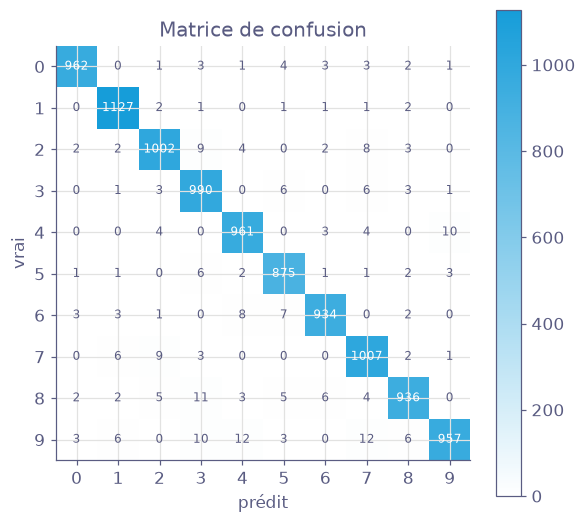

  12 fois : un 9 pris pour un 4
  12 fois : un 9 pris pour un 7
  11 fois : un 8 pris pour un 3


In [11]:
modele.eval()
with torch.no_grad():
    y_pred = modele(torch.from_numpy(X_test).float()).argmax(dim=1).numpy()

matrice = viz.plot_confusion(y_test, y_pred)

# Les trois confusions les plus fréquentes.
erreurs = matrice.copy()
np.fill_diagonal(erreurs, 0)
for _ in range(3):
    vrai, predit = np.unravel_index(erreurs.argmax(), erreurs.shape)
    print(f"{erreurs[vrai, predit]:4d} fois : un {vrai} pris pour un {predit}")
    erreurs[vrai, predit] = 0

Tu vas probablement voir des **4 ↔ 9**, des **3 ↔ 5**, des **7 ↔ 1**.

Ce sont exactement les paires qu'un humain confond aussi. Le modèle ne se trompe pas
n'importe comment : il se trompe sur ce qui est **réellement ambigu**. C'est plutôt
rassurant — et c'est un bon argument à ressortir quand quelqu'un vous demande si le modèle
« comprend » quelque chose.

### Et si on regardait les images ratées ?

249 erreurs sur 10000 images


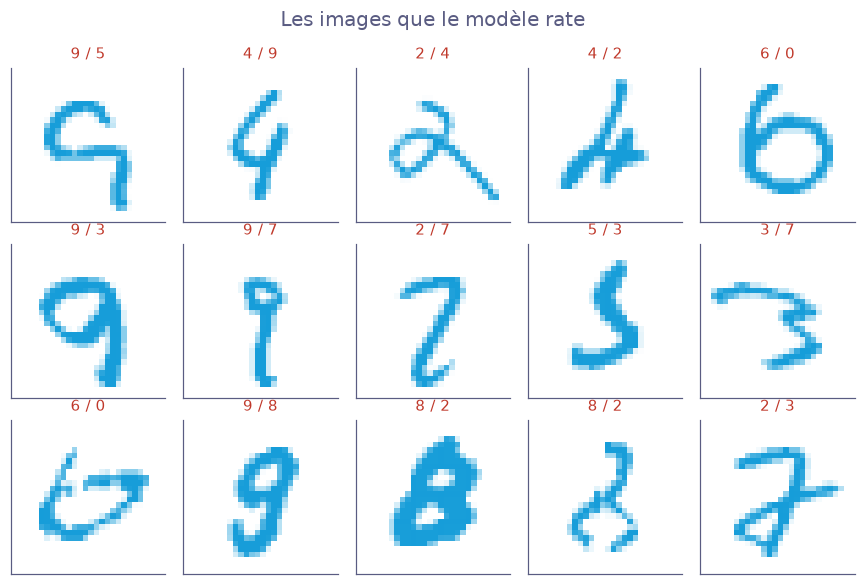

In [12]:
rates = y_pred != y_test
print(f"{rates.sum()} erreurs sur {len(y_test)} images")
viz.affiche_chiffres(X_test[rates], y_test[rates], y_pred[rates], n=15,
                     titre="Les images que le modèle rate")

Regarde-les honnêtement : **certaines sont franchement illisibles**. Toi non plus tu ne
saurais pas trancher.

C'est là que vit l'**erreur irréductible**. Une partie des 3 % restants n'est pas un défaut
du modèle : c'est du bruit dans les étiquettes. Courir après 100 % sur MNIST, c'est courir
après des images que personne ne sait lire.

> ### ✏️ À toi de jouer
>
> Choisis **une** expérience, lance-la, et rapporte le résultat au groupe :
>
> 1. Couche cachée de **16** neurones, puis de **1024**. Plus gros = mieux ? (Regarde aussi
>    le nombre de paramètres : x8 en taille, pour quel gain réel ?)
> 2. Remplacer `nn.ReLU()` par `nn.Sigmoid()`. Que devient la courbe ?
> 3. Ajouter `nn.Dropout(0.2)` après chaque ReLU. Effet sur l'écart train/validation ?
> 4. Entraîner sur des données **non normalisées** (`normalise=False`). Comparer.

   16 neurones → 91.89% de test  14 298 paramètres


  128 neurones → 94.46% de test  109 386 paramètres


 1024 neurones → 95.25% de test  870 090 paramètres


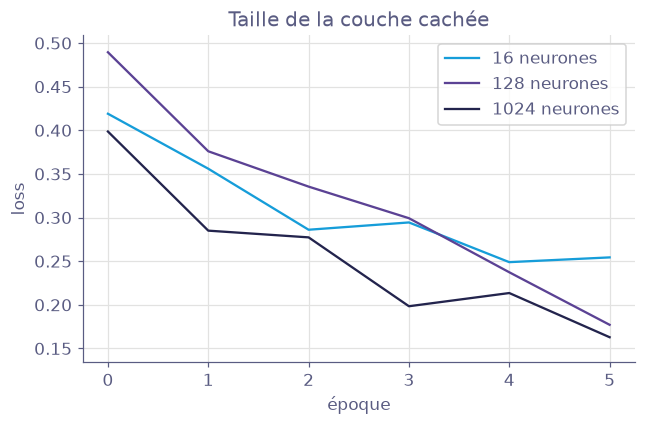

In [13]:
comparaison = {}
for taille in [16, 128, 1024]:
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(784, taille), nn.ReLU(),
                      nn.Linear(taille, 64), nn.ReLU(),
                      nn.Linear(64, 10))
    h = entraine(m, train_rapide, val_loader, eta=0.1, epoques=6, bavard=False)
    _, acc = evalue(m, test_loader, nn.CrossEntropyLoss())
    comparaison[f"{taille} neurones"] = h["validation"]
    n_p = sum(p.numel() for p in m.parameters())
    print(f"{taille:5} neurones → {acc:.2%} de test, {n_p:,} paramètres".replace(",", " "))

viz.plot_comparaison(comparaison, titre="Taille de la couche cachée")

On sauvegarde le modèle : le notebook 4 va s'en servir pour le casser.

In [14]:
torch.save(modele.state_dict(), RACINE / "data" / "mlp.pt")
print("modèle sauvegardé dans data/mlp.pt")

modèle sauvegardé dans data/mlp.pt


---
# À retenir

| | |
|---|---|
| **PyTorch n'a remplacé qu'une chose : ton `backward()`.** | Le reste a la même forme que ton code NumPy. |
| **`CrossEntropyLoss` mange des logits.** | Pas de softmax avant. Erreur n°1 des débutants. |
| **`zero_grad()` n'est pas décoratif.** | PyTorch accumule les gradients. |
| **`eta` se mesure, il ne se devine pas.** | Trop petit : ça rampe. Trop grand : `nan`. |
| **Adam pardonne un mauvais `eta`.** | C'est pour ça qu'il est le choix par défaut. |
| **L'accuracy seule ment.** | Matrice de confusion + regarder les images ratées. |
| **Une partie de l'erreur est irréductible.** | Certaines images ne sont lisibles par personne. |

### La suite

97 %, c'est bien. Mais ce modèle a une faiblesse qu'on n'a pas encore vue — et elle est
plus grave que les 3 % qui manquent.

→ **Notebook 4 : on casse le MLP.**